# Microgrid Dataset EDA and Reporting

## Final Dataset Column Reference Index & Identifier

### Identifier
- **DateTime**: 15-minute interval timestamp
- **NodeID**: Unique identifier for each site/node
- **DayOfWeek**: Day index (0=Monday, 6=Sunday)
- **IsHoliday**: US federal holiday flag (0/1)
- **Season**: Spring, Summer, Fall, Winter

### Demand & Generation
- **TotalLoad_kW**: Aggregated real power demand at node
- **PV_Power_kW**: Actual solar PV output at node
- **PV_Forecast_kW**: Predicted PV generation (prediction target)
- **LoadForecast_kW**: Predicted load demand (prediction target)
- **Net_Load_kW**: TotalLoad_kW − PV_Power_kW

### Weather
- **GHI_Wm2**: Global Horizontal Irradiance
- **AmbientTemp_C**: Ambient air temperature
- **Humidity_pct**: Relative humidity
- **CloudCoverIndex**: Sky clearness (0=overcast, 1=clear)

### Pricing & Grid
- **ElectricityPrice_USDkWh**: Time-of-use tariff rate at interval
- **DemandCharge_USDkW**: Peak demand charge rate
- **GridCarbonIntensity_gCO2kWh**: Grid carbon intensity for green dispatch
- **GridExportLimit_kW**: Net metering export cap at node

### Site Parameters (Static per Node)
- **NodeLatitude**: Geographic latitude
- **NodeLongitude**: Geographic longitude
- **TransmissionLimit_kW**: Max power flow capacity on feeder
- **SiteCapEx_USDkWh**: Capital cost of storage installation
- **SiteOpEx_USDkWh**: Operational cost per interval
- **CandidateSite_Flag**: Valid installation site (0/1)

### Decision Variables (Optimization Output)
- **StorageSize_kWh**: Optimal storage capacity to install at node
- **StorageSited_Binary**: Install storage at this node or not (0/1)

*Total: 27 columns. Rows without a candidate site still carry site parameter columns for completeness but CandidateSite_Flag = 0.*

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create 'image' folder if it doesn't exist
os.makedirs('image', exist_ok=True)

# Read the dataset
# If memory is tight due to the size (>50MB), we can sample or handle specific chunks, but we'll try reading it fully first.
try:
    df = pd.read_csv('microgrid_final_dataset.csv')
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    print("Dataset successfully loaded.")
    print(f"Shape: {df.shape}")
    display(df.head())
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset successfully loaded.
Shape: (3676302, 26)


,DateTime,NodeID,DayOfWeek,IsHoliday,Season,TotalLoad_kW,PV_Power_kW,PV_Forecast_kW,LoadForecast_kW,Net_Load_kW,...,GridCarbonIntensity_gCO2kWh,GridExportLimit_kW,NodeLatitude,NodeLongitude,TransmissionLimit_kW,SiteCapEx_USDkWh,SiteOpEx_USDkWh,CandidateSite_Flag,StorageSize_kWh,StorageSited_Binary
0,2015-01-01,LeichtagPV,3,1,Winter,0.000,0.009,NaN,NaN,-0.009,...,280,500.0,32.8807,-117.2361,900,435,0.019,1,NaN,NaN
1,2015-01-01,Mandeville,3,1,Winter,20.085,0.000,NaN,NaN,20.085,...,280,500.0,32.8796,-117.2416,750,415,0.017,0,NaN,NaN
2,2015-01-01,RadyHall,3,1,Winter,34.405,0.000,NaN,NaN,34.405,...,280,500.0,32.8739,-117.2324,800,420,0.018,1,NaN,NaN
3,2015-01-01,PepperCanyon,3,1,Winter,38.424,0.000,NaN,NaN,38.424,...,280,500.0,32.8762,-117.2355,700,410,0.017,1,NaN,NaN
4,2015-01-01,OttersonHall,3,1,Winter,73.551,0.000,NaN,NaN,73.551,...,280,500.0,32.8771,-117.2368,650,405,0.017,1,NaN,NaN


## 1. Time Series Visualizations: Overarching Trends

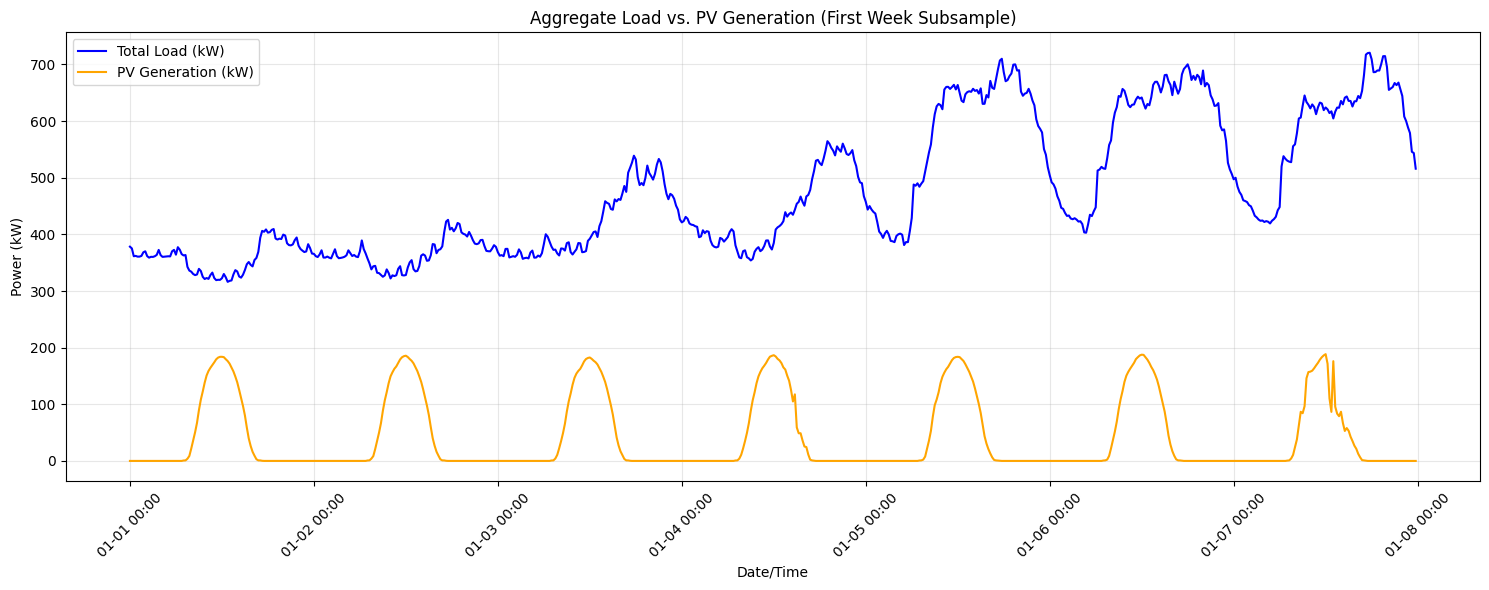

In [4]:
if 'df' in locals():
    # Aggregate total load and PV over all nodes per timestep to see overarching trends
    time_series_agg = df.groupby('DateTime')[['TotalLoad_kW', 'PV_Power_kW']].sum().reset_index()

    # Let's plot just a sub-sample (e.g., the first 7 days) so the chart isn't too cluttered
    one_week_df = time_series_agg.head(24 * 4 * 7) # 4 readings/hour * 24 hrs * 7 days

    plt.figure(figsize=(15, 6))
    plt.plot(one_week_df['DateTime'], one_week_df['TotalLoad_kW'], label='Total Load (kW)', color='blue')
    plt.plot(one_week_df['DateTime'], one_week_df['PV_Power_kW'], label='PV Generation (kW)', color='orange')
    
    plt.title('Aggregate Load vs. PV Generation (First Week Subsample)')
    plt.xlabel('Date/Time')
    plt.ylabel('Power (kW)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('image/time_series.png')
    plt.show()

## 2. Weather Impact Analysis

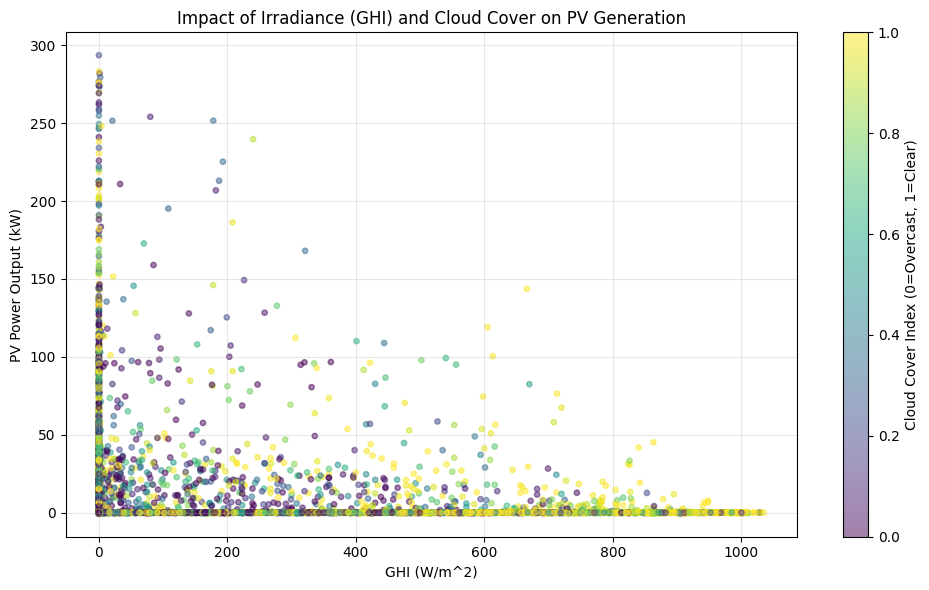

In [5]:
if 'df' in locals():
    # Scatter plot: Global Horizontal Irradiance vs PV Power
    # Sampling to improve render performance for large datasets
    sample_df = df.sample(n=min(10000, len(df)), random_state=42)

    plt.figure(figsize=(10, 6))
    # Use a scatter plot. Color by cloud cover index.
    sc = plt.scatter(sample_df['GHI_Wm2'], sample_df['PV_Power_kW'], 
                     c=sample_df['CloudCoverIndex'], cmap='viridis', alpha=0.5, s=15)
    
    plt.title('Impact of Irradiance (GHI) and Cloud Cover on PV Generation')
    plt.xlabel('GHI (W/m^2)')
    plt.ylabel('PV Power Output (kW)')
    plt.colorbar(sc, label='Cloud Cover Index (0=Overcast, 1=Clear)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('image/weather_impact.png')
    plt.show()

## 3. Pricing & Grid Profile

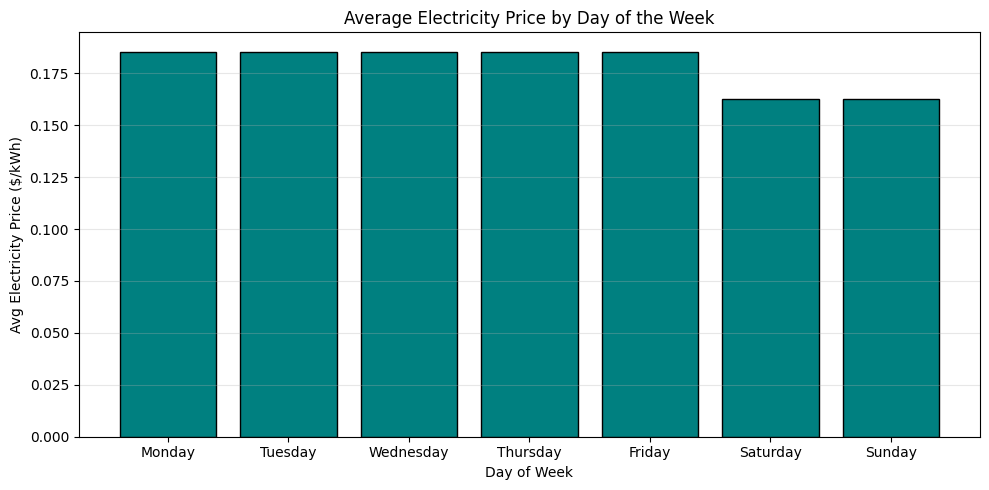

In [6]:
if 'df' in locals():
    # Grouping by DayOfWeek to see average electricity prices throughout the week
    day_price = df.groupby('DayOfWeek')['ElectricityPrice_USDkWh'].mean().reset_index()
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    plt.figure(figsize=(10, 5))
    plt.bar(day_price['DayOfWeek'], day_price['ElectricityPrice_USDkWh'], color='teal', edgecolor='black')
    plt.xticks(ticks=range(7), labels=days)
    plt.title('Average Electricity Price by Day of the Week')
    plt.ylabel('Avg Electricity Price ($/kWh)')
    plt.xlabel('Day of Week')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('image/pricing.png')
    plt.show()

## 4. Site Parameters & Candidates
Visualizing differences between locations labeled as active candidate sites (`CandidateSite_Flag = 1`) versus non-candidates.

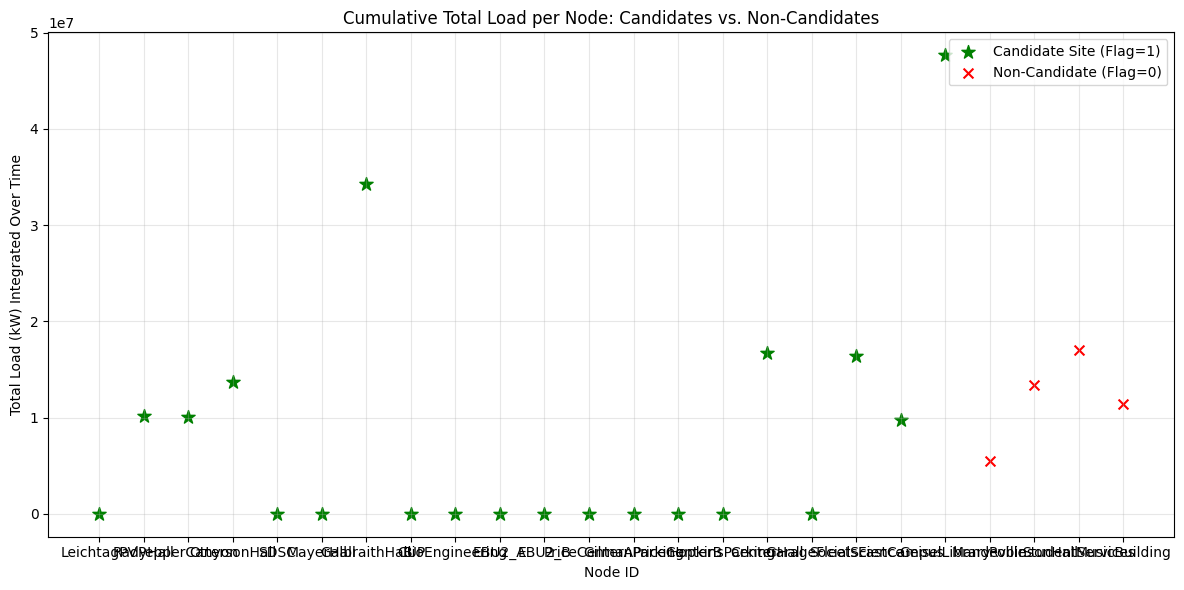

In [7]:
if 'df' in locals():
    # Get node-level static parameters by taking the first observation per node
    nodes_df = df.drop_duplicates(subset=['NodeID']).copy()
    
    # Total Load per node across the entire dataset
    node_totals = df.groupby('NodeID')['TotalLoad_kW'].sum().reset_index()
    nodes_df = nodes_df.merge(node_totals, on='NodeID', suffixes=('', '_Sum'))

    # Plotting
    plt.figure(figsize=(12, 6))
    
    candidates = nodes_df[nodes_df['CandidateSite_Flag'] == 1]
    non_candidates = nodes_df[nodes_df['CandidateSite_Flag'] == 0]

    plt.scatter(candidates['NodeID'], candidates['TotalLoad_kW_Sum'], 
                color='green', label='Candidate Site (Flag=1)', s=100, marker='*')
    plt.scatter(non_candidates['NodeID'], non_candidates['TotalLoad_kW_Sum'], 
                color='red', label='Non-Candidate (Flag=0)', s=50, marker='x')

    plt.title('Cumulative Total Load per Node: Candidates vs. Non-Candidates')
    plt.xlabel('Node ID')
    plt.ylabel('Total Load (kW) Integrated Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('image/site_parameters.png')
    plt.show()